In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
# load data from google drive
df = pd.read_csv(r"C:\Users\kadam\Desktop\Ride-Booking-Value-Prediction\data\raw\uber.csv")
df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [47]:
# Remove unnecessary columns
df.drop(['Unnamed: 0', 'key', 'passenger_count'], axis=1, inplace=True)

# Check missing values
df.isnull().sum()

fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
dtype: int64

In [48]:
df.dropna(inplace=True)

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 199999 entries, 0 to 199999
Data columns (total 6 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   fare_amount        199999 non-null  float64
 1   pickup_datetime    199999 non-null  object 
 2   pickup_longitude   199999 non-null  float64
 3   pickup_latitude    199999 non-null  float64
 4   dropoff_longitude  199999 non-null  float64
 5   dropoff_latitude   199999 non-null  float64
dtypes: float64(5), object(1)
memory usage: 10.7+ MB


In [50]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

df['year'] = df['pickup_datetime'].dt.year
df['month'] = df['pickup_datetime'].dt.month
df['day'] = df['pickup_datetime'].dt.day
df['hour'] = df['pickup_datetime'].dt.hour
df['weekday'] = df['pickup_datetime'].dt.weekday

df['is_peak_hr'] = (
    ((df['hour'] >= 7) & (df['hour'] <= 10)) |
    ((df['hour'] >= 16) & (df['hour'] <= 19))
).astype(int)

df['is_night'] = (
    (df['hour'] >= 20) |
    (df['hour'] <= 6)
).astype(int)

In [51]:
df.drop('pickup_datetime', axis=1, inplace=True)

In [52]:
from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    R = 6371

    lat1, lon1, lat2, lon2 = map(
        radians,
        [lat1, lon1, lat2, lon2]
    )

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2

    c = 2 * atan2(sqrt(a), sqrt(1-a))

    return R * c

df['distance_km'] = df.apply(
    lambda x: haversine(
        x['pickup_latitude'],
        x['pickup_longitude'],
        x['dropoff_latitude'],
        x['dropoff_longitude']
    ),
    axis=1
)

In [53]:
df = df[df['fare_amount'] > 0]

df = df[
    (df['pickup_longitude'].between(-75, -72)) &
    (df['dropoff_longitude'].between(-75, -72)) &
    (df['pickup_latitude'].between(40, 42)) &
    (df['dropoff_latitude'].between(40, 42))
]

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 195787 entries, 0 to 199999
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   fare_amount        195787 non-null  float64
 1   pickup_longitude   195787 non-null  float64
 2   pickup_latitude    195787 non-null  float64
 3   dropoff_longitude  195787 non-null  float64
 4   dropoff_latitude   195787 non-null  float64
 5   year               195787 non-null  int32  
 6   month              195787 non-null  int32  
 7   day                195787 non-null  int32  
 8   hour               195787 non-null  int32  
 9   weekday            195787 non-null  int32  
 10  is_peak_hr         195787 non-null  int32  
 11  is_night           195787 non-null  int32  
 12  distance_km        195787 non-null  float64
dtypes: float64(6), int32(7)
memory usage: 15.7 MB


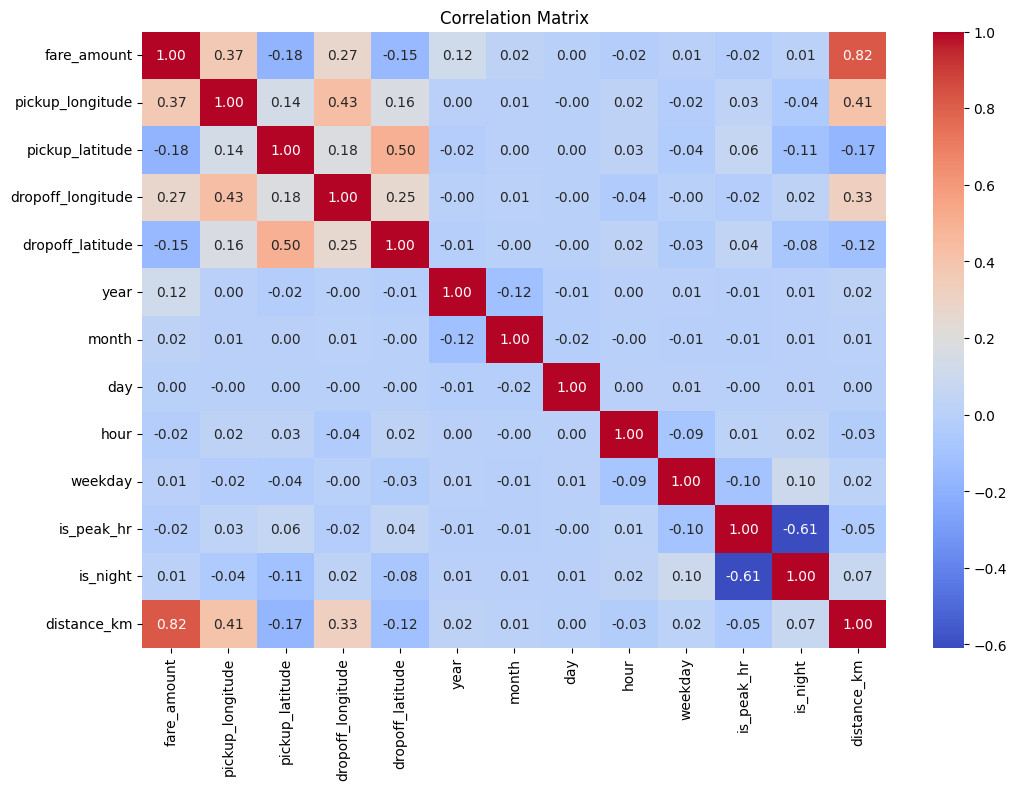

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

corr_matrix = df.select_dtypes(include=['number']).corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()

In [56]:
corr_with_target = (
    df.select_dtypes(include=['number'])
      .corr()['fare_amount']
      .sort_values(ascending=False)
)

print(corr_with_target)

fare_amount          1.000000
distance_km          0.822559
pickup_longitude     0.369879
dropoff_longitude    0.270418
year                 0.118704
month                0.024041
is_night             0.013446
weekday              0.006525
day                  0.000471
hour                -0.020838
is_peak_hr          -0.023437
dropoff_latitude    -0.151111
pickup_latitude     -0.184508
Name: fare_amount, dtype: float64


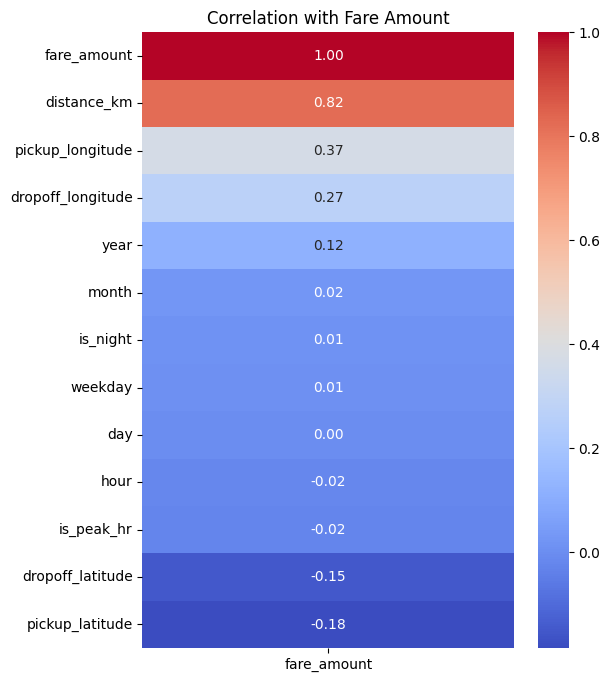

In [57]:
plt.figure(figsize=(6, 8))

sns.heatmap(
    corr_with_target.to_frame(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation with Fare Amount')
plt.show()

In [58]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=20
)

print(train_df.shape)
print(test_df.shape)

(156629, 13)
(39158, 13)


In [59]:
# save df to csv

train_df.to_csv(r"C:\Users\kadam\Desktop\Ride-Booking-Value-Prediction\data\processed\train.csv", index=False)
test_df.to_csv(r"C:\Users\kadam\Desktop\Ride-Booking-Value-Prediction\data\processed\test.csv", index=False)